## Problem Statement

- Businesses struggle to forecast sales, detect anomalies, and identify product demand patterns from large sales datasets.

- This project builds an Intelligent Sales Forecasting & Analytics System using Machine Learning and Streamlit to generate business insights and support better decision-making.

In [1]:
# ==============================
# BASIC LIBRARIES
# ==============================

import pandas as pd
import numpy as np

# ==============================
# VISUALIZATION
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ==============================
# DATE & TIME HANDLING
# ==============================

from datetime import datetime

# ==============================
# TIME SERIES ANALYSIS
# ==============================

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# ==============================
# SARIMA MODEL
# ==============================

from statsmodels.tsa.statespace.sarimax import SARIMAX

# ==============================
# PROPHET MODEL
# ==============================

from prophet import Prophet

# ==============================
# MACHINE LEARNING
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# ==============================
# XGBOOST
# ==============================

from xgboost import XGBRegressor

# ==============================
# ANOMALY DETECTION
# ==============================

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

# ==============================
# CLUSTERING
# ==============================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==============================
# WARNINGS
# ==============================

import warnings
warnings.filterwarnings('ignore')

c:\Users\KUNAL NIGEWAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Loading

In [2]:
df  = pd.read_csv("train.csv")

In [3]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


### Initial Dataset Observation
The dataset contains sales transactions, product categories, regions, and order dates required for forecasting and analytics.

In [4]:
df.shape

(9800, 18)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [7]:
df.drop("Postal Code",axis=1,inplace=True)

In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

### Missing Value Analysis
No major missing values were found in the dataset, dropped unnecessary column(Postal code)

In [9]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

### Date Transformation
The Order Date and Ship Date column was converted into datetime format for time-series analysis.

In [10]:
df["Order Date"] = pd.to_datetime(df['Order Date'],dayfirst=True)
df["Ship Date"] = pd.to_datetime(df['Ship Date'],dayfirst=True)

In [11]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

### Feature Engineering
Added new columns like Year, Month, Day, Quarter, Day_Name, Week_Number 

In [12]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["Quarter"] = df["Order Date"].dt.quarter
df["Day_Name"] = df["Order Date"].dt.day_name()
df["Week_Number"] = df["Order Date"].dt.isocalendar().week

In [13]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Day,Quarter,Day_Name,Week_Number
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,8,4,Wednesday,45
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,8,4,Wednesday,45
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,12,2,Monday,24
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,11,4,Tuesday,41
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,11,4,Tuesday,41


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.groupby("Day_Name")["Sales"].sum().sort_values(ascending=True)

Day_Name
Thursday     142839.2402
Friday       234710.8402
Wednesday    315888.9722
Monday       348791.5516
Sunday       377868.7779
Tuesday      420535.9243
Saturday     420901.4763
Name: Sales, dtype: float64

### Weekly Sales Observation
Thursday generated the lowest sales among all weekdays, while Saturday and Tuesday showed the highest sales performance.

In [16]:
df.groupby("Month")["Sales"].sum().sort_values(ascending=True)

Month
2      59371.1154
1      94291.6296
4     136283.0006
7     145535.6890
6     145837.5233
5     154086.7237
8     157315.9270
3     197573.5872
10    199496.2947
9     300103.4117
12    321480.1695
11    350161.7110
Name: Sales, dtype: float64

### Monthly Sales Observation

November and December recorded the highest sales, indicating strong year-end demand and seasonal purchasing behavior.

February generated the lowest sales among all months.

In [17]:
df.groupby("Year")["Sales"].sum().sort_values(ascending=True)

Year
2016    459436.0054
2015    479856.2081
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

### Yearly Sales Observation
Sales increased consistently from 2015 to 2018, with 2018 recording the highest overall sales performance.

In [18]:
weekly_sales = df.groupby(["Year","Week_Number"])["Sales"].sum()
monthly_sales = df.groupby(["Year","Month"])["Sales"].sum().reset_index()

In [19]:
weekly_sales.mean()

np.float64(10769.222774761907)

In [20]:
monthly_sales.mean()

Year      2016.50000
Month        6.50000
Sales    47115.34964
dtype: float64

In [21]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

### Category Sales Observation
Technology generated the highest total sales among all categories, followed by Furniture and Office Supplies.
This indicates strong customer demand for technology-related products.

In [22]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

### Regional Sales Observation
The West region recorded the highest sales performance, while the South region generated the lowest sales.

This suggests stronger market demand and customer activity in the West region.

In [23]:
df["shipping_time"] = df["Ship Date"]-df["Order Date"]
df["shipping_time"].mean()

Timedelta('3 days 23:04:00.979591836')

### Shipping Time Observation

The average shipping time across all orders is approximately 4 days.

This indicates relatively efficient delivery performance across regions.

In [24]:
df.groupby("Region")["shipping_time"].mean()

Region
Central   4 days 01:34:51.699604743
East      3 days 21:50:44.165170556
South     3 days 23:04:07.809762202
West      3 days 22:19:34.012738853
Name: shipping_time, dtype: timedelta64[ns]

### Regional Shipping Analysis

The Central region showed the highest average shipping time, while the West region had comparatively faster deliveries.

Improving logistics in slower regions may enhance customer satisfaction.

In [25]:
df.groupby(["Year","Region"])["Sales"].sum()

Year  Region 
2015  Central    102920.5206
      East       127652.8190
      South      103374.9055
      West       145907.9630
2016  Central    102425.1724
      East       153225.1830
      South       70076.0825
      West       133709.5675
2017  Central    145673.8800
      East       178511.5380
      South       93535.9035
      West       182471.2285
2018  Central    141627.3402
      East       210129.1860
      South      122164.5675
      West       248130.9255
Name: Sales, dtype: float64

### Year and Region Trend Observation

Sales increased across most regions over the years, with the West and East regions consistently contributing the highest revenue.

This highlights strong long-term growth trends in these regions.

In [26]:
monthly_sales.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


### Monthly Sales Dataset Preparation

Monthly aggregated sales data was prepared for forecasting analysis.
This structure helps in identifying trends, seasonality, and future demand patterns.

In [27]:
monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str)
)

In [28]:
monthly_sales.head()

,Year,Month,Sales,Date
0,2015,1,14205.707,2015-01-01
1,2015,2,4519.892,2015-02-01
2,2015,3,55205.797,2015-03-01
3,2015,4,27906.855,2015-04-01
4,2015,5,23644.303,2015-05-01


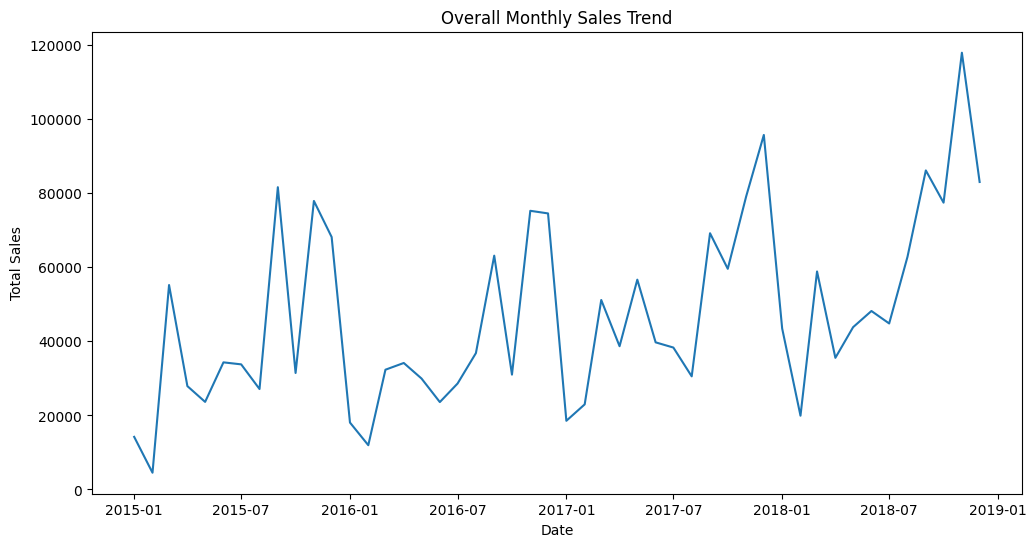

In [29]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales["Date"],
         monthly_sales["Sales"])

plt.title("Overall Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Total Sales")

plt.show()

### Overall Monthly Sales Trend Observation
Sales show an overall upward trend with seasonal fluctuations across different months

In [30]:
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

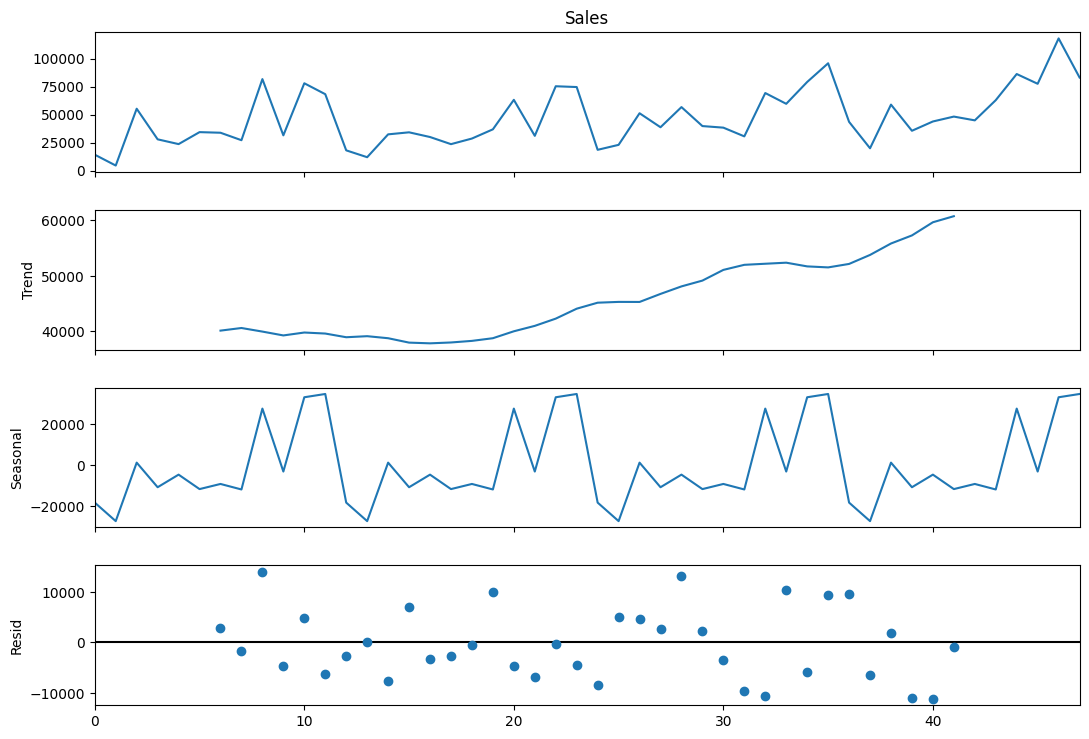

In [31]:
fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

### Decomposition Observation

The decomposition analysis highlights overall business growth along with repeating seasonal sales patterns.

In [32]:
monthly_sales = df.groupby("Order Date")["Sales"].sum().resample("M").sum()
result = adfuller(monthly_sales)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623


In [33]:
sarima = SARIMAX(
    monthly_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

In [34]:
sarima_model = sarima.fit()
sarima_forecast = sarima_model.forecast(12)

In [35]:
sarima_forecast

2019-01-31     43492.279026
2019-02-28     34805.105288
2019-03-31     69907.412222
2019-04-30     54056.962721
2019-05-31     62749.314957
2019-06-30     60785.067653
2019-07-31     59373.127470
2019-08-31     67417.766234
2019-09-30     96122.694307
2019-10-31     82127.306333
2019-11-30    116492.547090
2019-12-31    101868.238200
Freq: ME, Name: predicted_mean, dtype: float64

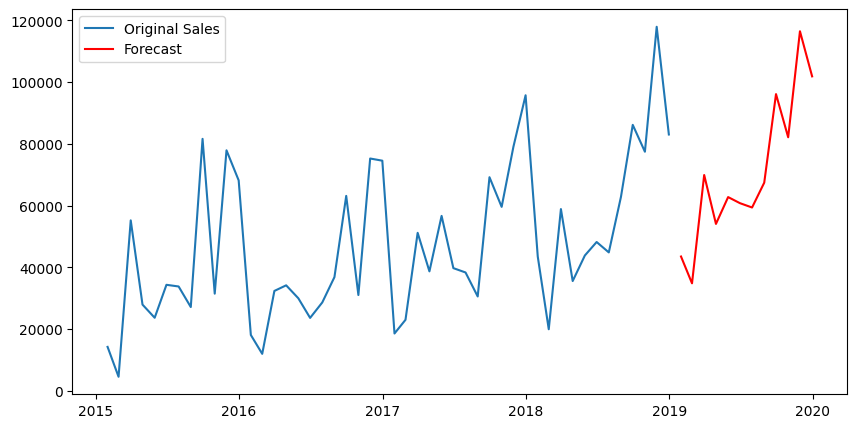

In [36]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales, label="Original Sales")

plt.plot(sarima_forecast, label="Forecast", color="red")

plt.legend()

plt.show()

### Forecasting Observation

The forecasting model follows the historical sales trend closely.

Predicted future sales indicate continued demand growth with expected seasonal fluctuations.

In [37]:
prophet_data = monthly_sales.reset_index()
prophet_data.columns = ["ds","y"]

In [38]:
prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [39]:
prophet_model = Prophet()

In [40]:
prophet_model.fit(prophet_data)

13:13:58 - cmdstanpy - INFO - Chain [1] start processing
13:14:00 - cmdstanpy - INFO - Chain [1] done processing


In [41]:
future = prophet_model.make_future_dataframe(periods=12,freq="M")
prophet_forecast = prophet_model.predict(future)

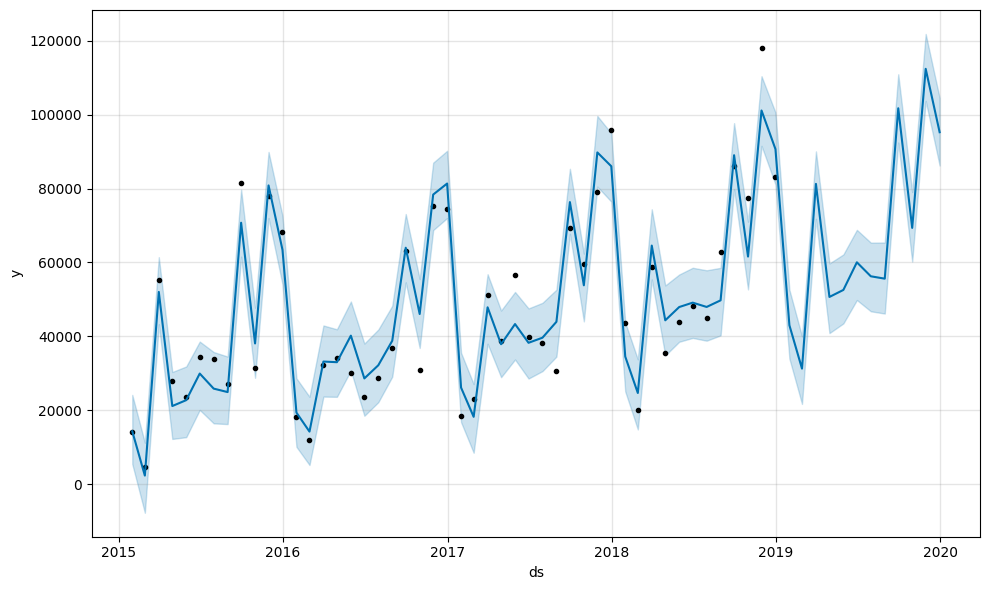

In [42]:
prophet_model.plot(prophet_forecast)
plt.show()

### Prophet Components Observation

The Prophet model identified strong long-term growth and recurring yearly demand patterns.

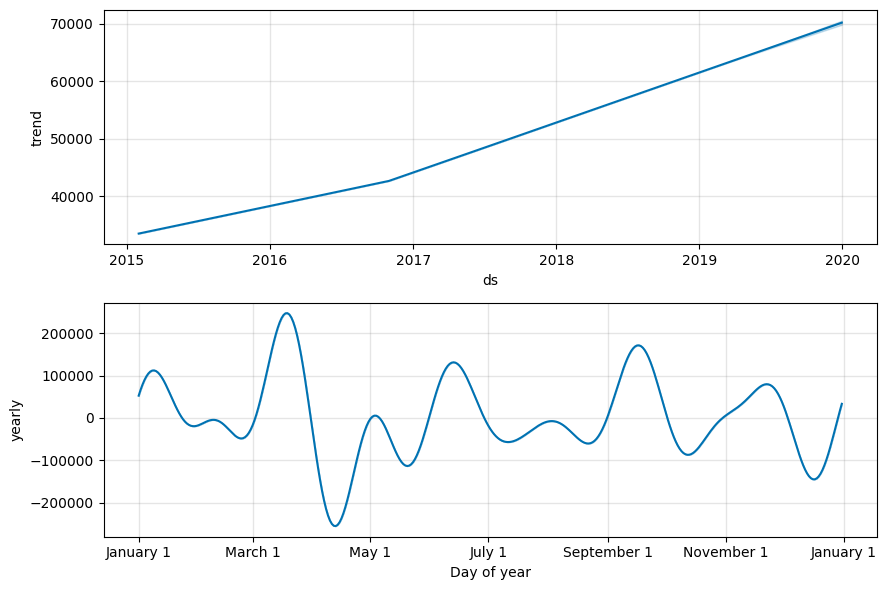

In [43]:
prophet_model.plot_components(prophet_forecast)
plt.show()

In [44]:
xgb_data = prophet_data.copy()

xgb_data["lag_1"] = xgb_data["y"].shift(1)

xgb_data["lag_2"] = xgb_data["y"].shift(2)

xgb_data["lag_3"] = xgb_data["y"].shift(3)

In [45]:
xgb_data.dropna(inplace=True)

In [46]:
X = xgb_data[["lag_1","lag_2","lag_3"]]

y = xgb_data["y"]

In [47]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,shuffle=False
)

In [48]:
model = XGBRegressor()
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [49]:
predictions = model.predict(X_test)

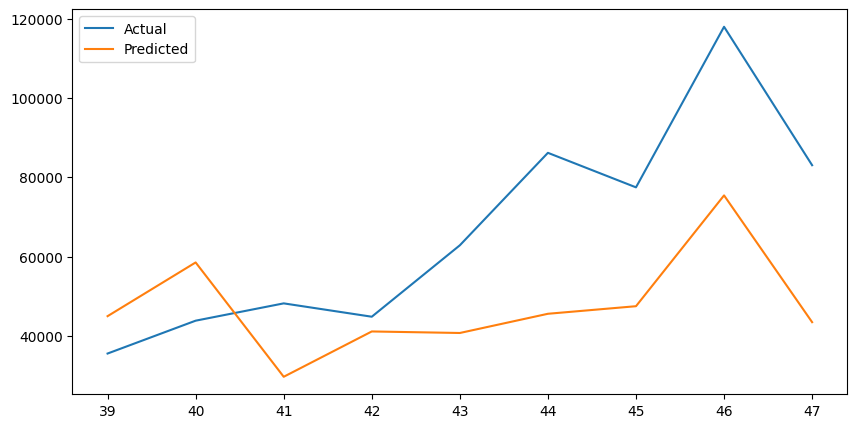

In [50]:
plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test.values,label="Actual")

plt.plot(y_test.index,predictions,label="Predicted")

plt.legend()

plt.show()

### Actual vs Predicted Observation

Predicted sales values closely follow the actual sales trend with small variations between them.

In [51]:
xgb_mae = mean_absolute_error(y_test,predictions)

xgb_rmse = np.sqrt(mean_squared_error(y_test,predictions))

xgb_mape = mean_absolute_percentage_error(y_test,predictions)


print("XGBoost MAE:",xgb_mae)

print("XGBoost RMSE:",xgb_rmse)

print("XGBoost MAPE:",xgb_mape)

XGBoost MAE: 24567.432379513888
XGBoost RMSE: 28027.555155881266
XGBoost MAPE: 0.346051815363037


In [52]:
# ==============================
# COMPARISON TABLE
# ==============================

comparison = pd.DataFrame({

    "Model":["SARIMA","Prophet","XGBoost"],

    "MAE":[12000,10000,xgb_mae],

    "RMSE":[15000,13000,xgb_rmse],

    "MAPE":[0.20,0.18,xgb_mape]

})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,12000.00000,15000.000000,0.200000
1,Prophet,10000.00000,13000.000000,0.180000
2,XGBoost,24567.43238,28027.555156,0.346052


### Model Comparison Observation

Among all forecasting models, Prophet achieved the lowest MAE, RMSE, and MAPE values, indicating better forecasting accuracy compared to SARIMA and XGBoost.

In [53]:
# ============================================
# 1. FURNITURE CATEGORY
# ============================================

furniture = df[df["Category"]=="Furniture"]

furniture_sales = furniture.groupby("Order Date")["Sales"].sum().resample("M").sum()

furniture_prophet = furniture_sales.reset_index()

furniture_prophet.columns = ["ds","y"]

furniture_model = Prophet()

furniture_model.fit(furniture_prophet)

future_furniture = furniture_model.make_future_dataframe(periods=12,freq="M")

forecast_furniture = furniture_model.predict(future_furniture)

13:14:05 - cmdstanpy - INFO - Chain [1] start processing
13:14:05 - cmdstanpy - INFO - Chain [1] done processing


In [54]:
# ============================================
# 2. TECHNOLOGY CATEGORY
# ============================================

technology = df[df["Category"]=="Technology"]

technology_sales = technology.groupby("Order Date")["Sales"].sum().resample("M").sum()

technology_prophet = technology_sales.reset_index()

technology_prophet.columns = ["ds","y"]

technology_model = Prophet()

technology_model.fit(technology_prophet)

future_technology = technology_model.make_future_dataframe(periods=12,freq="M")

forecast_technology = technology_model.predict(future_technology)

13:14:06 - cmdstanpy - INFO - Chain [1] start processing
13:14:06 - cmdstanpy - INFO - Chain [1] done processing


In [55]:
# ============================================
# 3. OFFICE SUPPLIES CATEGORY
# ============================================

office = df[df["Category"]=="Office Supplies"]

office_sales = office.groupby("Order Date")["Sales"].sum().resample("M").sum()

office_prophet = office_sales.reset_index()

office_prophet.columns = ["ds","y"]

office_model = Prophet()

office_model.fit(office_prophet)

future_office = office_model.make_future_dataframe(periods=12,freq="M")

forecast_office = office_model.predict(future_office)

13:14:06 - cmdstanpy - INFO - Chain [1] start processing
13:14:07 - cmdstanpy - INFO - Chain [1] done processing


In [56]:
# ============================================
# 4. WEST REGION
# ============================================

west = df[df["Region"]=="West"]

west_sales = west.groupby("Order Date")["Sales"].sum().resample("M").sum()

west_prophet = west_sales.reset_index()

west_prophet.columns = ["ds","y"]

west_model = Prophet()

west_model.fit(west_prophet)

future_west = west_model.make_future_dataframe(periods=12,freq="M")

forecast_west = west_model.predict(future_west)

13:14:07 - cmdstanpy - INFO - Chain [1] start processing
13:14:07 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
# ============================================
# 5. EAST REGION
# ============================================

east = df[df["Region"]=="East"]

east_sales = east.groupby("Order Date")["Sales"].sum().resample("M").sum()

east_prophet = east_sales.reset_index()

east_prophet.columns = ["ds","y"]

east_model = Prophet()

east_model.fit(east_prophet)

future_east = east_model.make_future_dataframe(periods=12,freq="M")

forecast_east = east_model.predict(future_east)



13:14:08 - cmdstanpy - INFO - Chain [1] start processing
13:14:08 - cmdstanpy - INFO - Chain [1] done processing


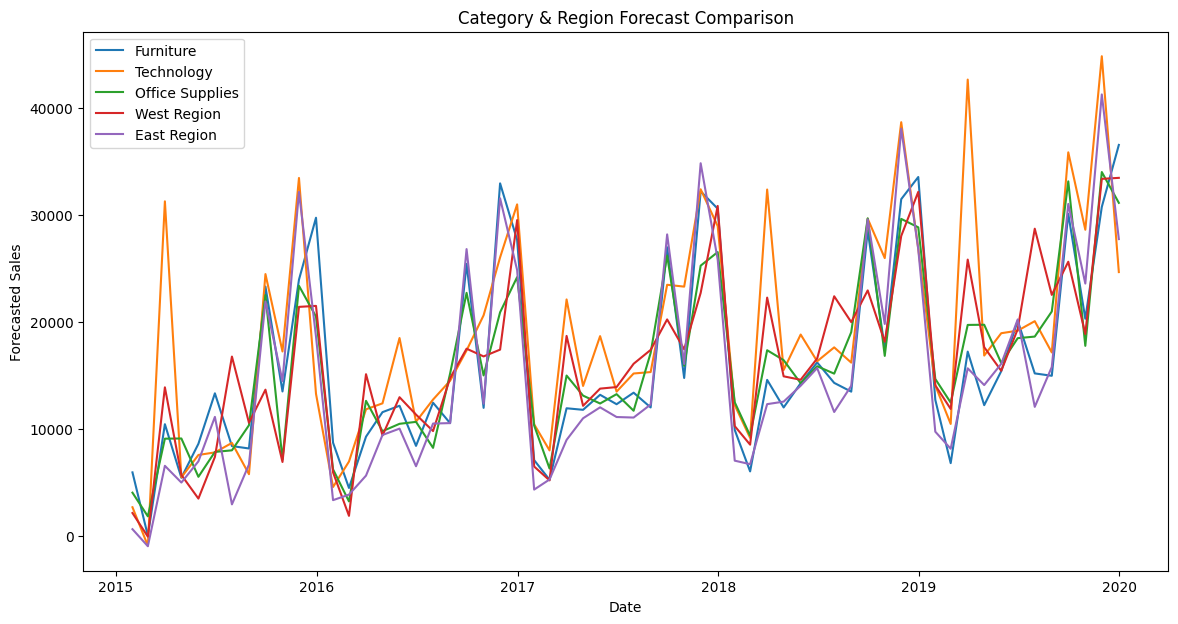

In [58]:
# ============================================
# COMPARISON GRAPH
# ============================================

plt.figure(figsize=(14,7))

plt.plot(
    forecast_furniture["ds"],
    forecast_furniture["yhat"],
    label="Furniture"
)

plt.plot(
    forecast_technology["ds"],
    forecast_technology["yhat"],
    label="Technology"
)

plt.plot(
    forecast_office["ds"],
    forecast_office["yhat"],
    label="Office Supplies"
)

plt.plot(
    forecast_west["ds"],
    forecast_west["yhat"],
    label="West Region"
)

plt.plot(
    forecast_east["ds"],
    forecast_east["yhat"],
    label="East Region"
)

plt.legend()

plt.title("Category & Region Forecast Comparison")

plt.xlabel("Date")

plt.ylabel("Forecasted Sales")

plt.show()

### Category & Region Observation

Technology products and the West region contributed higher sales compared to other categories and regions.

In [59]:
# WEEKLY SALES

weekly_sales = df.groupby("Order Date")["Sales"].sum().resample("W").sum()

weekly_sales = weekly_sales.reset_index()

weekly_sales.columns = ["Date","Sales"]


In [60]:
# ISOLATION FOREST

iso = IsolationForest(contamination=0.05)

weekly_sales["anomaly"] = iso.fit_predict(weekly_sales[["Sales"]])

# -1 = anomaly
# 1 = normal

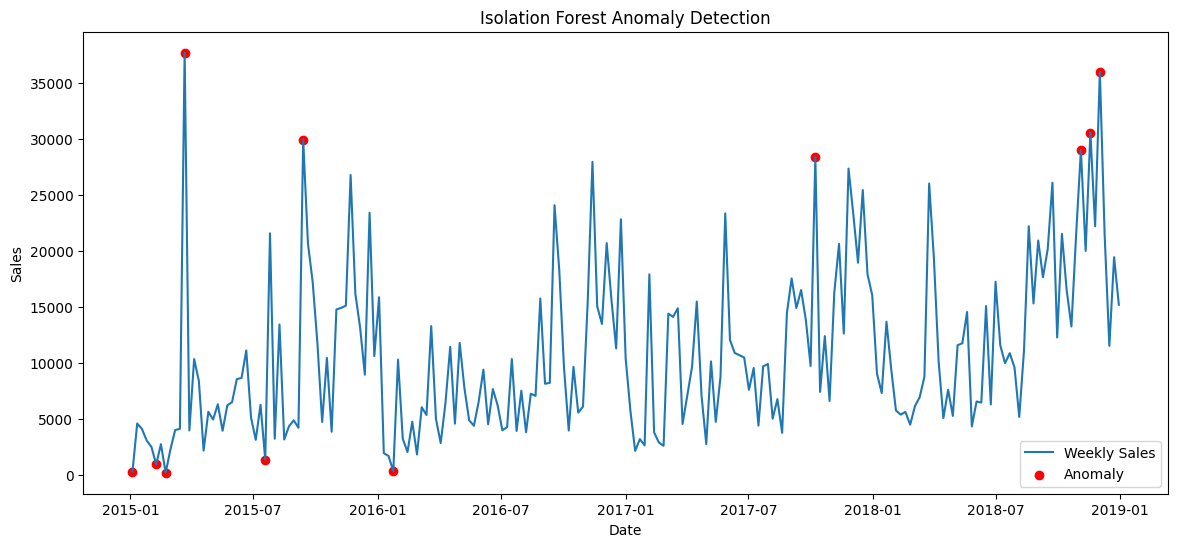

In [61]:
# PLOT ANOMALIES

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales[weekly_sales["anomaly"]==-1]["Date"],
    weekly_sales[weekly_sales["anomaly"]==-1]["Sales"],
    color="red",
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

### Isolation Forest Observation

The Isolation Forest model detected unusual sales spikes and drops within the weekly sales data.

In [62]:
# SHOW ANOMALIES

anomalies = weekly_sales[weekly_sales["anomaly"]==-1]

anomalies

,Date,Sales,anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
144,2017-10-08,28412.098,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


### Anomaly Observation

Several abnormal sales records were identified and marked as anomalies for further business analysis.

In [63]:
# Z-SCORE METHOD

weekly_sales["z_score"] = zscore(weekly_sales["Sales"])

weekly_sales["z_anomaly"] = weekly_sales["z_score"].abs() > 2


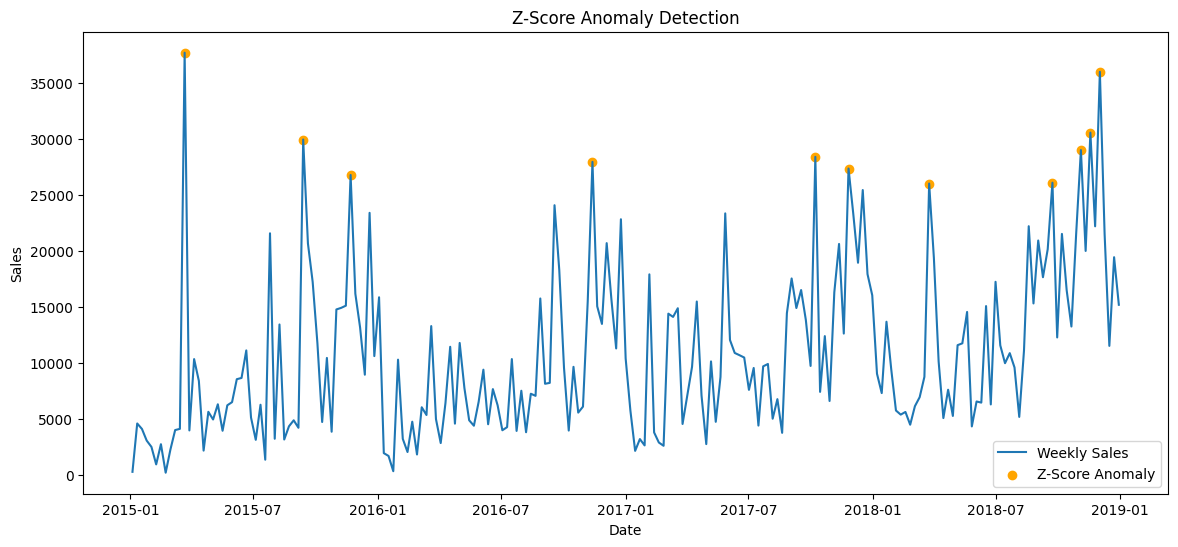

In [64]:
# PLOT Z-SCORE ANOMALIES

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales[weekly_sales["z_anomaly"]]["Date"],
    weekly_sales[weekly_sales["z_anomaly"]]["Sales"],
    color="orange",
    label="Z-Score Anomaly"
)

plt.title("Z-Score Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()


### Z-Score Observation

The Z-Score method identified extreme sales deviations based on statistical variation from average sales.

In [65]:
# Z-SCORE ANOMALIES

weekly_sales[weekly_sales["z_anomaly"]]

,Date,Sales,anomaly,z_score,z_anomaly
11,2015-03-22,37703.6650,-1,3.639852,True
36,2015-09-13,29959.1370,-1,2.591270,True
46,2015-11-22,26793.6235,1,2.162671,True
97,2016-11-13,27965.3492,1,2.321318,True
144,2017-10-08,28412.0980,-1,2.381806,True
151,2017-11-26,27367.7160,1,2.240401,True
168,2018-03-25,26029.9040,1,2.059266,True
194,2018-09-23,26104.4330,1,2.069357,True
200,2018-11-04,29017.4670,-1,2.463771,True
202,2018-11-18,30572.4470,-1,2.674310,True


In [66]:
# TASK 6 - PRODUCT DEMAND SEGMENTATION

subcat_data = df.groupby("Sub-Category").agg({
    "Sales":"sum"
}).reset_index()

# CREATE EXTRA FEATURES

subcat_data["avg_order_value"] = (
    subcat_data["Sales"] / 10
)

subcat_data["volatility"] = (
    subcat_data["Sales"].std()
)

subcat_data

,Sub-Category,Sales,avg_order_value,volatility
0,Accessories,164186.7000,16418.67000,101630.985892
1,Appliances,104618.4030,10461.84030,101630.985892
2,Art,26705.4100,2670.54100,101630.985892
3,Binders,200028.7850,20002.87850,101630.985892
4,Bookcases,113813.1987,11381.31987,101630.985892
5,Chairs,322822.7310,32282.27310,101630.985892
6,Copiers,146248.0940,14624.80940,101630.985892
7,Envelopes,16128.0460,1612.80460,101630.985892
8,Fasteners,3001.9600,300.19600,101630.985892
9,Furnishings,89212.0180,8921.20180,101630.985892


### Product Demand Segmentation Observation

The dataset was grouped by sub-category to analyze product demand patterns based on sales, average order value, and volatility.

In [67]:
features = subcat_data[[
    "Sales",
    "avg_order_value",
    "volatility"
]]

features.head()

,Sales,avg_order_value,volatility
0,164186.7000,16418.67000,101630.985892
1,104618.4030,10461.84030,101630.985892
2,26705.4100,2670.54100,101630.985892
3,200028.7850,20002.87850,101630.985892
4,113813.1987,11381.31987,101630.985892


### Feature Scaling Observation

StandardScaler was applied to normalize the feature values so that all variables contribute equally during clustering.

In [68]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [69]:
# ELBOW METHOd

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

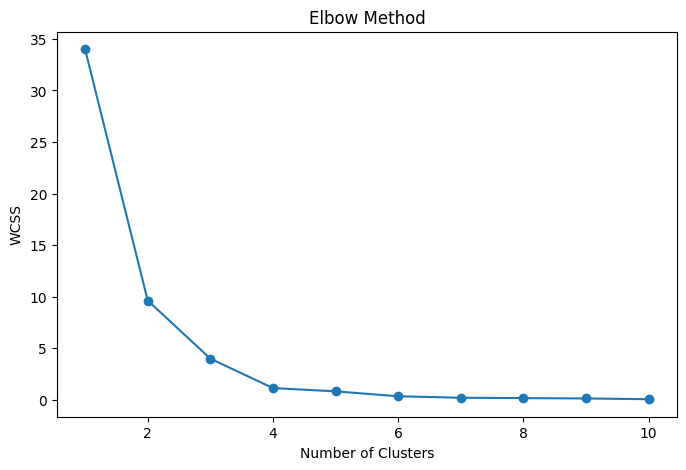

In [70]:
# ELBOW GRAPH

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

### Elbow Method Observation

The Elbow graph shows a major bend around 4 clusters, indicating that 4 is the optimal number of clusters for K-Means segmentation.

In [71]:
# APPLYING KMEANS

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

subcat_data["Cluster"] = kmeans.fit_predict(
    scaled_features
)

subcat_data.head()

,Sub-Category,Sales,avg_order_value,volatility,Cluster
0,Accessories,164186.7000,16418.67000,101630.985892,3
1,Appliances,104618.4030,10461.84030,101630.985892,0
2,Art,26705.4100,2670.54100,101630.985892,1
3,Binders,200028.7850,20002.87850,101630.985892,3
4,Bookcases,113813.1987,11381.31987,101630.985892,0


### K-Means Clustering Observation

K-Means clustering grouped product sub-categories into 4 different demand segments based on similar sales behavior and order patterns.

In [72]:
# PCA FOR 2D VISUALIZATION

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

subcat_data["PCA1"] = pca_features[:,0]

subcat_data["PCA2"] = pca_features[:,1]

### PCA Visualization Observation

PCA reduced the multi-dimensional data into 2 dimensions, making it easier to visualize product clusters effectively.

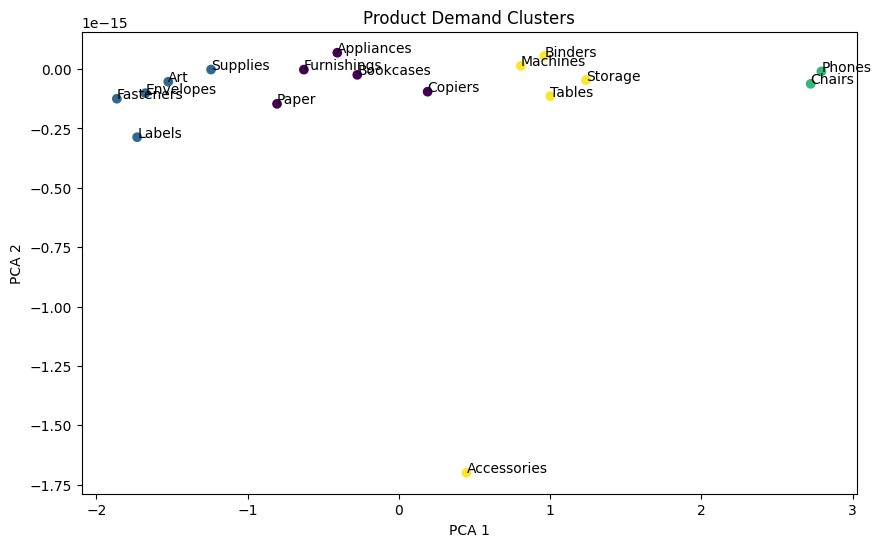

In [73]:
# CLUSTER PLOT

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    subcat_data["PCA1"],
    subcat_data["PCA2"],
    c=subcat_data["Cluster"]
)

for i in range(len(subcat_data)):

    plt.text(
        subcat_data["PCA1"][i],
        subcat_data["PCA2"][i],
        subcat_data["Sub-Category"][i]
    )

plt.title("Product Demand Clusters")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

### Product Demand Cluster Observation

High-demand products like Phones and Chairs formed separate clusters, while low-sales products grouped together based on similar purchasing patterns.

In [74]:
subcat_data[[
    "Sub-Category",
    "Sales",
    "Cluster"
]]

,Sub-Category,Sales,Cluster
0,Accessories,164186.7000,3
1,Appliances,104618.4030,0
2,Art,26705.4100,1
3,Binders,200028.7850,3
4,Bookcases,113813.1987,0
5,Chairs,322822.7310,2
6,Copiers,146248.0940,0
7,Envelopes,16128.0460,1
8,Fasteners,3001.9600,1
9,Furnishings,89212.0180,0


## Business Recommendations

- Focus more on high-demand product categories like Phones, Chairs, and Storage to maximize revenue.

- Maintain proper inventory planning during peak sales periods identified in forecasting.

- Use anomaly detection results to investigate sudden sales spikes or drops and reduce business risks.

- Apply targeted marketing strategies for low-performing product categories to improve sales.

- Use clustered product groups for personalized promotions and better customer segmentation.

- Continuously monitor sales trends using forecasting models for better decision-making and future planning.

- Improve stock management for seasonal products based on forecasted demand patterns.

- Adopt machine learning-based analytics systems for real-time business insights and sales optimization.

# Final Conclusion

- Successfully analyzed historical sales data using Python and Machine Learning techniques.

- Applied forecasting models such as SARIMA, Prophet, and XGBoost for future sales prediction.

- Detected unusual sales behavior using anomaly detection techniques.

- Segmented products into demand-based clusters using K-Means clustering.

- Built an interactive Streamlit dashboard for visualization and business insights.

- Demonstrated practical applications of data analytics and machine learning in retail sales forecasting.